# Notebook 3 of 3 -- Decide, Measure, Monitor: BARGAIN routing, PPI evaluation, PPRM drift alarms

**Recap of Notebook 2.** A synthetic corpus of 4,800 job postings (9 latent classes, ~20% reposts, a month-5/6
buzzword wave) runs through a keyword-taxonomy rule tier (26.3% unresolved) and a real DeepSeek (`deepseek-flash`)
LLM tier. On the n=300 audit, pipeline precision was 0.576 [0.456, 0.688] and recall 0.745 [0.611, 0.845]. Rules made
1,513 errors on 4,800 postings, the LLM made 39, and the boundary sweep showed error falling from 0.142 (hi=4) to 0.046
(hi=12) as more postings go to the LLM.

**What this notebook adds** -- the three papers of Notebook 1, applied to that stack:

| Step | Paper | Question it answers here |
|---|---|---|
| Decide | BARGAIN (Zeighami, Shankar, Parameswaran; SIGMOD 2026) | How many postings can the cheap rules answer, with a guarantee? |
| Measure | PPI (Angelopoulos et al.; *Science* 2023) | What is each month's true GenAI-role prevalence, from 100 human labels? |
| Monitor | PPRM (Zhang, Cai, Yu, Simeone; ICML 2026) | Did the pipeline get *worse*, or did the data merely change? |

**Research constraints this notebook honours:**
- BARGAIN's accuracy is measured **against the oracle's outputs, not human labels**, on a **static batch**.
  Its guarantee holds even for badly calibrated proxy scores; only its *utility* needs calibration.
- PPI assumes labeled and unlabeled data are **i.i.d. from one distribution** and the predictor is **independent of the
  labeled data**. It only beats a classical interval when the predictor is accurate enough (App. G.1).
- PPRM alarms on a **harmful rise of the running risk**, not on any distribution change, needs labels every step,
  and uses δ_S=0.05, δ_T=0.2, η_0=1, n_t=1, N_t=15 by default.
- **No paper combines these three into one monthly lifecycle.** That combination is this project's design.

**Spend policy.** Everything below reuses DeepSeek responses already cached by Notebook 2. The only new calls are a
3-posting smoke test of the logprob proxy and thinking oracle (cached too), and a hard cap makes a cold re-run fail
rather than spend more. Scaling those calls up is left to the reader (see the closing section).

## 1. Reload Notebook 2's pipeline, and smoke-test the DeepSeek proxy/oracle

In [1]:
%matplotlib inline
import io, json, contextlib, math, hashlib
from pathlib import Path

# Execute Notebook 2's pipeline cells verbatim, so prompts are byte-identical and every call is a cache hit.
_NB2 = json.load(open(Path.cwd() / "02_project_walkthrough_part1.ipynb"))
for _i in [3, 4, 7, 11, 12, 14, 18, 22, 26, 27]:
    _src = "\n".join(l for l in "".join(_NB2["cells"][_i]["source"]).splitlines() if not l.lstrip().startswith("%"))
    with contextlib.redirect_stdout(io.StringIO()):
        exec(compile(_src, f"nb2_cell_{_i}", "exec"))

MAX_LIVE_CALLS = LLM_STATS["live_calls"] + 6   # hard cap: at most the 6 smoke-test calls below on a cold cache
print(f"reloaded {len(ALL_POSTINGS)} postings; live DeepSeek calls so far: {LLM_STATS['live_calls']}")

# Smoke test: cheap proxy (thinking off, 1 token, logprobs) vs oracle (thinking on) on 3 unresolved postings.
PROXY_SYSTEM = ("You label job postings for a hiring-signal platform.\n\n" + LABEL_GUIDE +
    "\n\nJudge ONLY the Responsibilities. Buzzwords in the title, skills or company blurb do not count; "
    "merely using ChatGPT/Copilot as a tool does not count.\n"
    "Answer with exactly one word: YES if the posting is genai_substantive, otherwise NO.")
def _msgs(p): return [{"role": "system", "content": PROXY_SYSTEM}, {"role": "user", "content": p["text"]}]
def proxy_score(p):
    r = deepseek_chat({"model": MODEL, "messages": _msgs(p), "max_tokens": 1, "temperature": 0,
                       "thinking": {"type": "disabled"}, "logprobs": True, "top_logprobs": 5},
                      section="nb3_proxy", kind="proxy_logprob")
    top = r["choices"][0]["logprobs"]["content"][0]["top_logprobs"]
    py = sum(math.exp(t["logprob"]) for t in top if t["token"].strip().lower() == "yes")
    pn = sum(math.exp(t["logprob"]) for t in top if t["token"].strip().lower() == "no")
    return py / (py + pn) if py + pn > 0 else 0.5
def oracle_answer(p):
    r = deepseek_chat({"model": MODEL, "messages": _msgs(p), "max_tokens": 2000, "thinking": {"type": "enabled"}},
                      section="nb3_oracle", kind="oracle_thinking")
    return (r["choices"][0]["message"].get("content") or "").strip().upper(), r["usage"]

SMOKE = [p for p in ALL_POSTINGS if RULE_DECISIONS[p["id"]] == "unresolved" and p["month"] <= 4][:3]
SMOKE_ROWS = []
for p in SMOKE:
    s = proxy_score(p); ans, usage = oracle_answer(p)
    SMOKE_ROWS.append((p["id"], p["latent_class"], p["label"], s, ans, usage.get("completion_tokens_details", {}).get("reasoning_tokens", 0)))
    print(f"{p['id']} {p['latent_class']:<18} truth={p['label']}  proxy P(YES)={s:.6f}  oracle={ans}  reasoning_tokens={SMOKE_ROWS[-1][-1]}")
print(f"live DeepSeek calls after smoke test: {LLM_STATS['live_calls']} (cap {MAX_LIVE_CALLS})")
print("note: the proxy probabilities are saturated at 0 or 1 -- a calibration problem for BARGAIN's utility, not its validity (q7)")

reloaded 4800 postings; live DeepSeek calls so far: 0
P000002 B_decorated        truth=0  proxy P(YES)=0.000000  oracle=NO  reasoning_tokens=40
P000009 C_genai_implicit   truth=1  proxy P(YES)=1.000000  oracle=YES  reasoning_tokens=171
P000010 B_decorated        truth=0  proxy P(YES)=0.000000  oracle=NO  reasoning_tokens=33
live DeepSeek calls after smoke test: 0 (cap 6)
note: the proxy probabilities are saturated at 0 or 1 -- a calibration problem for BARGAIN's utility, not its validity (q7)


## 2. Decide: how many postings can the rules answer, with a guarantee? (BARGAIN)

**Setup, as BARGAIN defines it.** A *proxy* answers cheaply, an *oracle* is expensive, and a cascade threshold ρ on
the proxy's confidence decides who answers. An Accuracy-Target query asks for the fewest oracle calls such that
$P(A(Y) \ge T) \ge 1-\delta$, where $A(Y)$ is the share of answers that **agree with the oracle**. Here the proxy is the
rule tier (unresolved postings use the 2.0 fallback), its confidence is the distance of the rule score from that
fallback midpoint, and the oracle is Notebook 2's cached LLM label. The batch is fixed: months 1-4 (BARGAIN's own
guarantee is defined on a static batch).

**Certification (Lemma B.1, Algorithm 3 / Lemma 3.5; defaults T=0.9, δ=0.1, M=20, η=0).** Scan candidate
thresholds from high to low. If the proxy answers the set $D_\rho$, the whole batch meets $T$ exactly when the proxy's
agreement on $D_\rho$ is at least $T_\rho = 1-(1-T)\,|D|/|D_\rho|$ (*derived here*). Certify that with the Lemma B.1
betting wealth at $1/\delta$, drawing oracle labels uniformly **with replacement** from $D_\rho$ (so the i.i.d. lemma
applies exactly; a simplification of the paper's without-replacement Lemma B.2). Stop at the first threshold that fails
(η=0). Oracle calls = postings routed to the oracle + distinct postings sampled for certification.

In [2]:
def lemma_b1_wealth(y, m, alpha):
    # BARGAIN Lemma B.1 (q5), with the standard predictable plug-in mean/variance (see Notebook 1, section 4).
    i = np.arange(1, len(y) + 1)
    mu = (0.5 + np.cumsum(y)) / (i + 1)
    sig2 = (0.25 + np.cumsum((y - mu) ** 2)) / (i + 1)
    sig2_prev = np.concatenate([[0.25], sig2[:-1]])
    lam = np.minimum(np.sqrt(2 * np.log(2 / alpha) / (i * np.log(i + 1) * sig2_prev)), 3 / (4 * m))
    return np.exp(np.cumsum(np.log(np.maximum(1 + lam * (y - m), 1e-300))))

D = [p for p in ALL_POSTINGS if p["month"] <= 4]
d_score = np.array([RULE_SCORES[p["id"]] for p in D])
d_proxy = np.array([1 if RULE_DECISIONS[p["id"]] == "pos" else 0 if RULE_DECISIONS[p["id"]] == "neg"
                    else int(RULE_SCORES[p["id"]] >= FALLBACK_MIDPOINT) for p in D])
d_oracle = np.array([int(bool(ALL_LLM_LABELS[p["id"]]["genai_substantive"])) for p in D])
d_truth = np.array([p["label"] for p in D])
d_conf = np.abs(d_score - FALLBACK_MIDPOINT)
T_AT, DELTA, SAMPLE_CAP = 0.9, 0.1, 400
CANDS = np.unique(np.quantile(d_conf, np.linspace(0, 0.95, 20)))[::-1]

def route_accuracy_target(rng):
    n, revealed, chosen = len(D), np.zeros(len(D), bool), None
    for rho in CANDS:
        idx = np.nonzero(d_conf > rho)[0]
        t_rho = 1 - (1 - T_AT) * n / len(idx)
        if t_rho <= 0:
            chosen = rho; continue
        draws = rng.choice(idx, size=SAMPLE_CAP, replace=True)
        hit = np.nonzero(lemma_b1_wealth((d_proxy[draws] == d_oracle[draws]).astype(float), t_rho, DELTA) >= 1 / DELTA)[0]
        revealed[draws[: (hit[0] + 1) if len(hit) else SAMPLE_CAP]] = True
        if len(hit) == 0:
            break
        chosen = rho
    use_proxy = d_conf > chosen if chosen is not None else np.zeros(n, bool)
    answer = np.where(use_proxy, d_proxy, d_oracle)
    calls = int((~use_proxy).sum() + (revealed & use_proxy).sum())
    return chosen, answer, calls

runs = [route_accuracy_target(np.random.default_rng(s)) for s in range(200)]
acc_oracle = np.array([np.mean(a == d_oracle) for _, a, _ in runs])
acc_truth = np.array([np.mean(a == d_truth) for _, a, _ in runs])
calls = np.array([c for _, _, c in runs])
AGREE_BY_RHO = [(rho, int((d_conf > rho).sum()), float(np.mean(d_proxy[d_conf > rho] == d_oracle[d_conf > rho])),
                 1 - (1 - T_AT) * len(D) / max(1, (d_conf > rho).sum())) for rho in CANDS]

nb2_unres = np.array([RULE_DECISIONS[p["id"]] == "unresolved" for p in D])
CONFIGS = {   # answers on the months 1-4 batch, and the share of postings each sends to the LLM
    "rules only (fallback)": (d_proxy, 0.0),
    "NB2 pipeline (hi=4)": (np.where(nb2_unres, d_oracle, d_proxy), nb2_unres.mean()),
    "certified routing (T=0.9)": (runs[0][1], calls.mean() / len(D)),
    "LLM on everything": (d_oracle, 1.0),
}
print(f"batch |D| = {len(D)} postings; {len(CANDS)} distinct candidate thresholds (coarse rule scores)")
print(f"SELF-CHECK: empirical P(accuracy vs oracle < T={T_AT}) over 200 runs = {np.mean(acc_oracle < T_AT):.3f} "
      f"(expected <= delta={DELTA}) -> {'MET' if np.mean(acc_oracle < T_AT) <= DELTA else 'NOT MET'}")
print(f"certified routing: oracle calls avoided = {1 - calls.mean() / len(D):.1%} (mean), "
      f"accuracy vs oracle = {acc_oracle.mean():.3f}, accuracy vs TRUTH = {acc_truth.mean():.3f}")
for name, (ans, share) in CONFIGS.items():
    print(f"  {name:<26} to LLM {share:6.1%}   acc vs oracle {np.mean(ans == d_oracle):.3f}   acc vs truth {np.mean(ans == d_truth):.3f}")
print("reading: the guarantee is about agreeing with the LLM; truth accuracy is a separate question (answered by PPI, section 4)")

batch |D| = 3200 postings; 9 distinct candidate thresholds (coarse rule scores)
SELF-CHECK: empirical P(accuracy vs oracle < T=0.9) over 200 runs = 0.015 (expected <= delta=0.1) -> MET
certified routing: oracle calls avoided = 8.1% (mean), accuracy vs oracle = 0.945, accuracy vs TRUTH = 0.939
  rules only (fallback)      to LLM   0.0%   acc vs oracle 0.704   acc vs truth 0.703
  NB2 pipeline (hi=4)        to LLM  23.1%   acc vs oracle 0.861   acc vs truth 0.857
  certified routing (T=0.9)  to LLM  91.9%   acc vs oracle 0.953   acc vs truth 0.947
  LLM on everything          to LLM 100.0%   acc vs oracle 1.000   acc vs truth 0.990
reading: the guarantee is about agreeing with the LLM; truth accuracy is a separate question (answered by PPI, section 4)


**How to read this chart.** Left: for each candidate threshold (x = how many postings the rules would answer), the rules'
agreement with the LLM on that set (bars) against the agreement needed to keep the whole batch at T=0.9 (dots).
Certification succeeds only where the bar clears the dot, and it stops at the first failure. Notice the agreement is **not
monotone** in the rule confidence: the rule score is a badly calibrated proxy, which is exactly the utility problem
BARGAIN's own calibration caveat warns about. Right: accuracy against the LLM oracle and against the (synthetic) truth for
four routing policies, with the share sent to the LLM. The certified policy keeps its promise *vs the oracle*; the truth
column is what an audit must still measure.

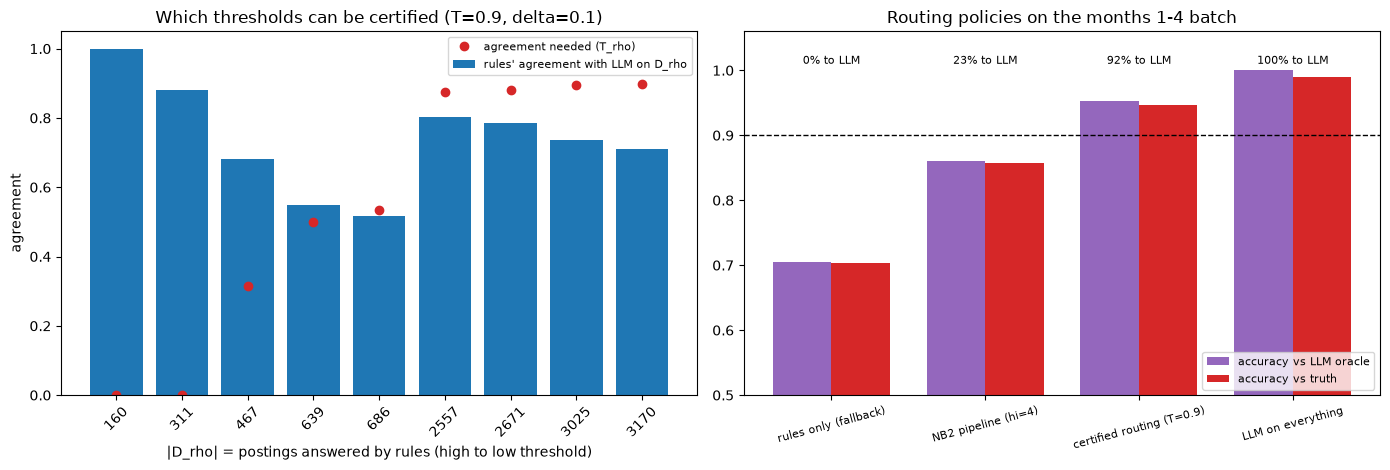

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
xs = np.arange(len(AGREE_BY_RHO))
ax.bar(xs, [a for _, _, a, _ in AGREE_BY_RHO], color=PALETTE["rules"], label="rules' agreement with LLM on D_rho")
ax.plot(xs, [max(t, 0) for *_, t in AGREE_BY_RHO], "o", color=PALETTE["truth"], label="agreement needed (T_rho)")
ax.set_xticks(xs); ax.set_xticklabels([str(k) for _, k, _, _ in AGREE_BY_RHO], rotation=45)
ax.set_xlabel("|D_rho| = postings answered by rules (high to low threshold)"); ax.set_ylabel("agreement")
ax.set_title("Which thresholds can be certified (T=0.9, delta=0.1)"); ax.legend(fontsize=8)
ax = axes[1]
names = list(CONFIGS); xc = np.arange(len(names)); w = 0.38
ax.bar(xc - w / 2, [np.mean(CONFIGS[k][0] == d_oracle) for k in names], w, color=PALETTE["llm"], label="accuracy vs LLM oracle")
ax.bar(xc + w / 2, [np.mean(CONFIGS[k][0] == d_truth) for k in names], w, color=PALETTE["truth"], label="accuracy vs truth")
for x_, k in zip(xc, names):
    ax.text(x_, 1.01, f"{CONFIGS[k][1]:.0%} to LLM", ha="center", fontsize=8)
ax.axhline(T_AT, color="black", ls="--", lw=1)
ax.set_xticks(xc); ax.set_xticklabels(names, rotation=15, fontsize=8); ax.set_ylim(0.5, 1.06)
ax.set_title("Routing policies on the months 1-4 batch"); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

## 3. Dedup before sampling: MinHash-LSH on posting text

PPI's validity rests on i.i.d. samples, and ~20% of postings are reposts of an earlier one. Sampling an audit from a
corpus with reposts double-counts some postings. So we remove near-duplicates first. MinHash and LSH are *derived here*
(Broder 1997; Leskovec, Rajaraman & Ullman, *Mining of Massive Datasets*, ch. 3), not from the three papers. Word
3-gram shingles, k=64 MinHashes, 16 bands of 4; candidate pairs are confirmed with exact Jaccard ≥ 0.6, and scored
against the generator's `dup_of` ground truth.

In [4]:
def shingles(text):
    w = re.findall(r"[a-z0-9]+", text.lower())
    return {" ".join(w[i:i + 3]) for i in range(len(w) - 2)}
SH = {p["id"]: shingles(p["text"]) for p in ALL_POSTINGS}
# Universal hashing h -> (a*h + b) mod p with p the largest 32-bit prime and a, b drawn over the FULL range [0, p):
# small multipliers against a huge modulus barely wrap, so all 64 functions order shingles almost the same way and
# MinHash agreement is biased below the true Jaccard. With h, a, b < p < 2^32 the product still fits in uint64.
PRIME, K_HASH, BANDS = 4294967291, 64, 16
_rng = np.random.default_rng(SEED + 3)
_A = _rng.integers(1, PRIME, K_HASH, dtype=np.uint64); _B = _rng.integers(0, PRIME, K_HASH, dtype=np.uint64)
def minhash(s):
    h = np.array([int.from_bytes(hashlib.blake2b(x.encode(), digest_size=8).digest(), "little") % PRIME for x in s], dtype=np.uint64)
    return ((h[None, :] * _A[:, None] + _B[:, None]) % np.uint64(PRIME)).min(axis=1)
SIG = {pid: minhash(s) for pid, s in SH.items()}
buckets = {}
for pid, sig in SIG.items():
    for b in range(BANDS):
        buckets.setdefault((b, sig[b * 4:(b + 1) * 4].tobytes()), []).append(pid)
cand = {tuple(sorted((x, y))) for ids in buckets.values() for i, x in enumerate(ids) for y in ids[i + 1:]}
jac = lambda a, b: len(SH[a] & SH[b]) / max(1, len(SH[a] | SH[b]))
DETECTED = {pr for pr in cand if jac(*pr) >= 0.6}
TRUE_PAIRS = {tuple(sorted((p["id"], p["dup_of"]))) for p in ALL_POSTINGS if p["dup_of"]}
tp = len(DETECTED & TRUE_PAIRS)
print(f"candidate pairs {len(cand)}, confirmed {len(DETECTED)}, true repost pairs {len(TRUE_PAIRS)}")
print(f"duplicate-pair precision {tp / max(1, len(DETECTED)):.3f}, recall {tp / len(TRUE_PAIRS):.3f}")
DROP = {max(a, b) for a, b in DETECTED}      # keep the earlier id of each detected pair
DEDUP = [p for p in ALL_POSTINGS if p["id"] not in DROP]
print(f"kept {len(DEDUP)} of {len(ALL_POSTINGS)} postings after dedup")
_true_j = [jac(*pr) for pr in TRUE_PAIRS]
_rand = [(ALL_POSTINGS[i]["id"], ALL_POSTINGS[j]["id"]) for i, j in np.random.default_rng(1).integers(0, len(ALL_POSTINGS), (2000, 2)) if i != j]
_rand_j = [jac(*pr) for pr in _rand]

candidate pairs 116512, confirmed 1209, true repost pairs 960
duplicate-pair precision 0.788, recall 0.993
kept 3801 of 4800 postings after dedup


**How to read this chart.** Jaccard similarity of word 3-gram shingles for true repost pairs (orange) and random pairs
(grey), with the 0.6 confirmation cut. If the two distributions barely overlap, a single cut separates reposts cleanly,
and the printed precision/recall above say how cleanly.

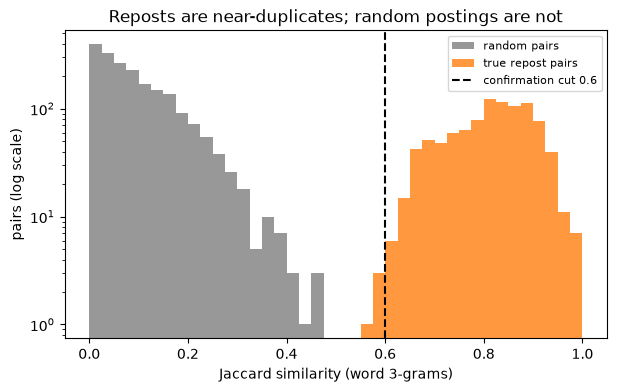

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(_rand_j, bins=40, range=(0, 1), color=PALETTE["neg"], alpha=0.8, label="random pairs")
ax.hist(_true_j, bins=40, range=(0, 1), color=PALETTE["unresolved"], alpha=0.8, label="true repost pairs")
ax.axvline(0.6, color="black", ls="--", label="confirmation cut 0.6")
ax.set_yscale("log"); ax.set_xlabel("Jaccard similarity (word 3-grams)"); ax.set_ylabel("pairs (log scale)")
ax.set_title("Reposts are near-duplicates; random postings are not"); ax.legend(fontsize=8)
plt.show()

## 4. Measure: monthly prevalence from 100 human labels (PPI)

**Estimator (PPI Algorithm 1).** With $n$ human-labeled postings and $N$ unlabeled ones in the same month,
$\hat\theta_{PP} = \frac1N\sum f(\tilde X_i) - \frac1n\sum (f(X_i)-Y_i)$, with interval
$\hat\theta_{PP} \pm z_{1-\alpha/2}\sqrt{\hat\sigma^2_{f-Y}/n + \hat\sigma^2_f/N}$. Validity needs i.i.d. samples from one
month (we sample within a month, from the deduped corpus) and a predictor independent of the audit labels (Notebook 2's
prompt was fixed before any audit). **When it helps (App. G.1):** only if $\mathrm{Var}(f-Y) < \mathrm{Var}(Y)$, i.e.
the predictor's error is below the break-even (about 9.5% at 10% prevalence, per the paper).

We compare, per month, over 500 random audits of n=100: the classical Wilson interval, PPI with the **pipeline** label as
$f$ (≈14% error), and PPI with the **LLM** label as $f$ (≈1% error). The truth is known, so coverage is checkable.

In [6]:
Z = NormalDist().inv_cdf(0.975); N_AUDIT, REPS = 100, 500
PPI_ROWS = []
rng = np.random.default_rng(SEED + 4)
for m in range(1, 7):
    ps = [p for p in DEDUP if p["month"] == m]
    y = np.array([p["label"] for p in ps]); theta = y.mean()
    f_pipe = np.array([PIPELINE[p["id"]]["final_label"] for p in ps])
    f_llm = np.array([int(bool(ALL_LLM_LABELS[p["id"]]["genai_substantive"])) for p in ps])
    res = {"classical": [], "PPI f=pipeline": [], "PPI f=LLM": []}
    for _ in range(REPS):
        perm = rng.permutation(len(ps)); lab, unl = perm[:N_AUDIT], perm[N_AUDIT:]
        lo, hi = wilson_ci(int(y[lab].sum()), N_AUDIT)
        res["classical"].append((lo <= theta <= hi, hi - lo))
        for key, f in (("PPI f=pipeline", f_pipe), ("PPI f=LLM", f_llm)):
            rect = f[lab] - y[lab]
            est = f[unl].mean() - rect.mean()
            w = Z * np.sqrt(rect.var() / N_AUDIT + f[unl].var() / len(unl))
            res[key].append((est - w <= theta <= est + w, 2 * w))
    PPI_ROWS.append({"month": m, "n_month": len(ps), "theta": theta,
                     **{k: (np.mean([c for c, _ in v]), np.mean([w for _, w in v])) for k, v in res.items()}})
print(f"{'month':>5} {'N':>5} {'truth':>6} | coverage / mean width:  classical | PPI f=pipeline | PPI f=LLM")
for r in PPI_ROWS:
    print(f"{r['month']:>5} {r['n_month']:>5} {r['theta']:>6.3f} | " + " | ".join(f"{r[k][0]:.3f} / {r[k][1]:.3f}"
          for k in ("classical", "PPI f=pipeline", "PPI f=LLM")))
cov_ok = all(r[k][0] >= 0.90 for r in PPI_ROWS for k in ("classical", "PPI f=pipeline", "PPI f=LLM"))
print(f"SELF-CHECK: every method keeps coverage >= 0.90 in every month (nominal 0.95, 500 audits) -> {'MET' if cov_ok else 'NOT MET'}")
ratio_llm = np.mean([r["PPI f=LLM"][1] / r["classical"][1] for r in PPI_ROWS])
ratio_pipe = np.mean([r["PPI f=pipeline"][1] / r["classical"][1] for r in PPI_ROWS])
print(f"mean width vs classical: PPI f=LLM {ratio_llm:.2f}x, PPI f=pipeline {ratio_pipe:.2f}x "
      f"(the more accurate predictor buys the narrower interval, as App. G.1 predicts)")

month     N  truth | coverage / mean width:  classical | PPI f=pipeline | PPI f=LLM
    1   640  0.198 | 0.958 / 0.154 | 0.952 / 0.160 | 1.000 / 0.076
    2   636  0.204 | 0.958 / 0.155 | 0.966 / 0.169 | 1.000 / 0.072
    3   632  0.215 | 0.970 / 0.158 | 0.962 / 0.160 | 1.000 / 0.083
    4   633  0.197 | 0.974 / 0.154 | 0.966 / 0.161 | 1.000 / 0.073
    5   630  0.214 | 0.976 / 0.158 | 0.958 / 0.170 | 1.000 / 0.075
    6   630  0.195 | 0.976 / 0.152 | 0.962 / 0.164 | 1.000 / 0.070
SELF-CHECK: every method keeps coverage >= 0.90 in every month (nominal 0.95, 500 audits) -> MET
mean width vs classical: PPI f=LLM 0.48x, PPI f=pipeline 1.06x (the more accurate predictor buys the narrower interval, as App. G.1 predicts)


**How to read this chart.** Left: mean 95% interval width per month for a 100-label audit; lower is better. Right: how
often each interval contained the true prevalence across 500 audits (dashed line = nominal 0.95). A good result is PPI
with the LLM label as predictor sitting far below classical on the left while staying near 0.95 on the right: the same
100 human labels, a much tighter answer. PPI with the noisier pipeline label gains less, because its error is close to
the break-even.

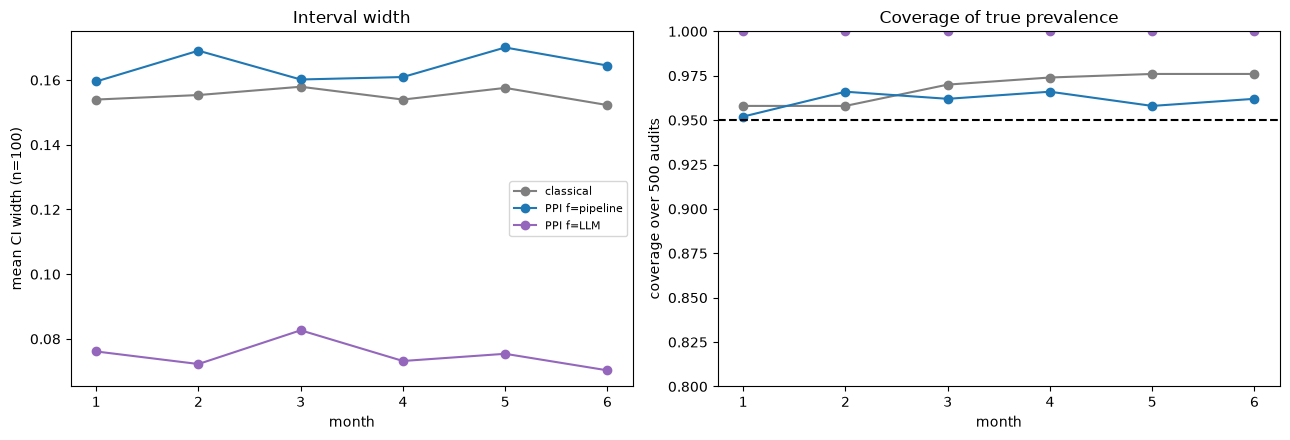

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
months = [r["month"] for r in PPI_ROWS]
colors = {"classical": PALETTE["neg"], "PPI f=pipeline": PALETTE["rules"], "PPI f=LLM": PALETTE["llm"]}
for k, c in colors.items():
    axes[0].plot(months, [r[k][1] for r in PPI_ROWS], "o-", color=c, label=k)
    axes[1].plot(months, [r[k][0] for r in PPI_ROWS], "o-", color=c, label=k)
axes[0].set_xlabel("month"); axes[0].set_ylabel("mean CI width (n=100)"); axes[0].set_title("Interval width"); axes[0].legend(fontsize=8)
axes[1].axhline(0.95, color="black", ls="--"); axes[1].set_ylim(0.8, 1.0)
axes[1].set_xlabel("month"); axes[1].set_ylabel("coverage over 500 audits"); axes[1].set_title("Coverage of true prevalence")
plt.tight_layout(); plt.show()

## 5. Monitor: harmful drift or harmless change? (PPRM)

**Test.** Running risk $\bar R_t=\frac1t\sum R_{t'}$; alarm when a lower confidence bound $L_t$ on it exceeds
$U_0+\epsilon_{tol}$, with type-I error at most $\delta_S+\delta_T$ (Theorem 3.2). PPRM builds $L_t$ from the Eq. 18
prediction-powered risk (one human label plus 15 synthetically labeled postings per step) with Lemma 2.1's CM-EB bound
(implemented with $q(\lambda)$ discretized, as in Notebook 1). SRM uses the human label alone. Defaults:
δ_S=0.05, δ_T=0.2, η=1, n_t=1, N_t=15. Here the loss is "pipeline label ≠ human label", the synthetic labeler $f_p$ is
the LLM label, and each step samples i.i.d. from that month's deduped postings (PPRM's per-step i.i.d. assumption).
$U_0$ is a Wilson upper bound from 1,000 month-1 labels (*derived here*; the paper uses a betting bound), and
$\epsilon_{tol}=0.02$.

**Two streams, 250 steps per month:**
1. **Buzzword wave, as built** (months 5-6 have many more decorated postings). The *data* changes, a naive frequency test
   notices, but pipeline error stays flat (Notebook 2) -- a harmless change, so PPRM should stay silent.
2. **LLM-tier outage from month 3**: unresolved postings silently fall back to the rules. Error rises -- a harmful shift,
   so PPRM should alarm, and faster than SRM when the synthetic labeler is good.

In [8]:
LAMS = (np.arange(200) + 0.5) / 200; PSIS = -np.log(1 - LAMS) - LAMS
def cmeb_lower(Zs, delta):
    t = np.arange(1, Zs.shape[1] + 1)[None, :]
    mu = np.cumsum(Zs, 1) / t
    zhat = np.concatenate([np.full((Zs.shape[0], 1), 0.5), np.clip(mu[:, :-1], 0, 1)], 1)
    V = np.cumsum((Zs - zhat) ** 2, 1)
    vt = np.concatenate([[0.0], np.geomspace(1e-3, max(V.max(), 1e-2), 3000)])
    logmix = lambda S: np.log(np.mean(np.exp(np.minimum(LAMS[None] * S[:, None] - PSIS[None] * vt[:, None], 700)), 1))
    lo, hi = np.zeros_like(vt), np.full_like(vt, 1.0)
    while (logmix(hi) < np.log(1 / delta)).any(): hi = np.where(logmix(hi) < np.log(1 / delta), hi * 2, hi)
    for _ in range(50):
        mid = (lo + hi) / 2; below = logmix(mid) < np.log(1 / delta); lo, hi = np.where(below, mid, lo), np.where(below, hi, mid)
    return mu - np.interp(V, vt, lo) / t
def first_alarm(L, thr):
    c = L > thr
    return np.where(c.any(1), c.argmax(1) + 1, -1)

DELTA_S, DELTA_T, EPS_TOL, ETA, STEPS, R_STREAMS, OUTAGE_MONTH = 0.05, 0.2, 0.02, 1.0, 250, 100, 3
llm_lab = {p["id"]: int(bool(ALL_LLM_LABELS[p["id"]]["genai_substantive"])) for p in DEDUP}
def month_arrays(m, outage):
    ps = [p for p in DEDUP if p["month"] == m]
    lab = np.array([(int(RULE_SCORES[p["id"]] >= FALLBACK_MIDPOINT) if (outage and PIPELINE[p["id"]]["decided_by"] == "llm")
                     else PIPELINE[p["id"]]["final_label"]) for p in ps])
    return (lab != np.array([p["label"] for p in ps])).astype(float), (lab != np.array([llm_lab[p["id"]] for p in ps])).astype(float)
def stream(outage, rng):
    U, UL, UU, true_err = [], [], [], []
    for m in range(1, 7):
        loss, disagree = month_arrays(m, outage and m >= OUTAGE_MONTH)
        li = rng.integers(0, len(loss), (R_STREAMS, STEPS)); ui = rng.integers(0, len(loss), (R_STREAMS, STEPS, 15))
        U.append(loss[li]); UL.append(disagree[li]); UU.append(disagree[ui].mean(2)); true_err += [loss.mean()] * STEPS
    u, uL, uU = (np.concatenate(a, 1) for a in (U, UL, UU))
    return u, (ETA * uU + u - ETA * uL + ETA) / (1 + 2 * ETA), np.cumsum(true_err) / np.arange(1, 6 * STEPS + 1)

rng = np.random.default_rng(SEED + 5)
loss1, _ = month_arrays(1, False)
cal = rng.choice(loss1, 1000)
U0 = wilson_ci(int(cal.sum()), 1000, alpha=2 * DELTA_S)[1]
THR = U0 + EPS_TOL; THR_PP = (THR + ETA) / (1 + 2 * ETA)
MONITOR = {}
for name, outage in (("buzzword wave", False), ("LLM outage from month 3", True)):
    u, zpp, run_risk = stream(outage, rng)
    L_srm, L_pp = cmeb_lower(u, DELTA_T), cmeb_lower(zpp, DELTA_T) * (1 + 2 * ETA) - ETA
    a_srm, a_pp = first_alarm(L_srm, THR), first_alarm(L_pp, THR)
    t_star = int(np.argmax(run_risk > THR) + 1) if (run_risk > THR).any() else None
    MONITOR[name] = dict(L_srm=L_srm[0], L_pp=L_pp[0], run_risk=run_risk, a_srm=a_srm, a_pp=a_pp, t_star=t_star)
    med = lambda a: np.median(a[a > 0]) if (a > 0).any() else float("nan")
    print(f"{name}: true running risk crosses threshold at t*={t_star}; alarm rate SRM {np.mean(a_srm > 0):.2f} "
          f"(median t {med(a_srm):.0f}), PPRM {np.mean(a_pp > 0):.2f} (median t {med(a_pp):.0f})")
print(f"U0 = {U0:.3f}, alarm threshold U0 + eps_tol = {THR:.3f}")
ok_benign = np.mean(MONITOR["buzzword wave"]["a_pp"] > 0) <= DELTA_S + DELTA_T
ok_harm = np.mean(MONITOR["LLM outage from month 3"]["a_pp"] > 0) >= 0.9
print(f"SELF-CHECK: PPRM stays silent on the harmless buzzword wave (alarm rate <= {DELTA_S + DELTA_T}) -> {'MET' if ok_benign else 'NOT MET'}")
print(f"SELF-CHECK: PPRM alarms on the outage in >= 90% of streams -> {'MET' if ok_harm else 'NOT MET'}")

def decorated(p):
    mt = RULE_MATCHES[p["id"]]
    return bool(mt.get("title") or mt.get("skills") or mt.get("blurb")) and not mt.get("responsibilities")
pre = np.array([decorated(p) for p in DEDUP if p["month"] <= 4]); post = np.array([decorated(p) for p in DEDUP if p["month"] >= 5])
pool = np.concatenate([pre, post]).mean()
z_stat = (post.mean() - pre.mean()) / np.sqrt(pool * (1 - pool) * (1 / len(pre) + 1 / len(post)))
print(f"naive two-proportion test on 'buzzwords without GenAI responsibilities': months 1-4 {pre.mean():.3f} vs "
      f"months 5-6 {post.mean():.3f}, z = {z_stat:.1f} -> flags a change that did NOT hurt the pipeline")

buzzword wave: true running risk crosses threshold at t*=None; alarm rate SRM 0.01 (median t 4), PPRM 0.00 (median t nan)


LLM outage from month 3: true running risk crosses threshold at t*=672; alarm rate SRM 1.00 (median t 1036), PPRM 1.00 (median t 803)
U0 = 0.162, alarm threshold U0 + eps_tol = 0.182
SELF-CHECK: PPRM stays silent on the harmless buzzword wave (alarm rate <= 0.25) -> MET
SELF-CHECK: PPRM alarms on the outage in >= 90% of streams -> MET
naive two-proportion test on 'buzzwords without GenAI responsibilities': months 1-4 0.075 vs months 5-6 0.193, z = 10.8 -> flags a change that did NOT hurt the pipeline


**How to read this chart.** Each panel is one monitoring stream. The black curve is the true running risk; grey and blue
are the SRM and PPRM lower bounds, which should stay below it; the red dashed line is the alarm threshold. An alarm fires
when a lower bound climbs over the red line. Left (buzzword wave): the true running risk never reaches the threshold, so
neither bound should cross -- the data changed, the pipeline did not get worse. Right (LLM outage): risk climbs after
month 3 (step 500), and the bounds follow it over the line; PPRM, helped by 15 synthetic labels per step, should clear
it first.

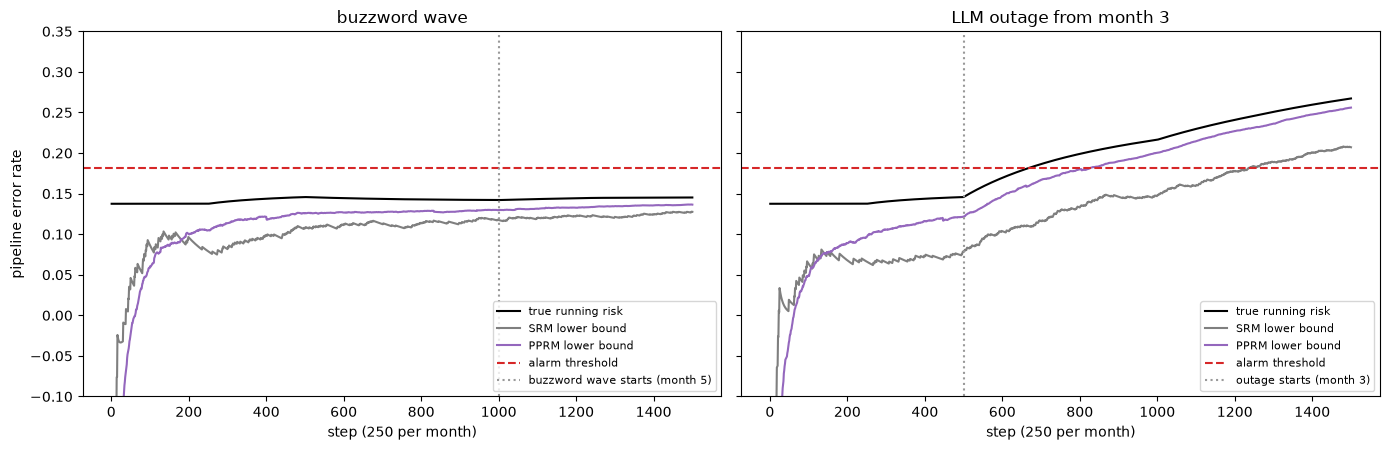

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
for ax, (name, r) in zip(axes, MONITOR.items()):
    t = np.arange(1, len(r["run_risk"]) + 1)
    ax.plot(t, r["run_risk"], color="black", label="true running risk")
    ax.plot(t, r["L_srm"], color=PALETTE["neg"], label="SRM lower bound")
    ax.plot(t, r["L_pp"], color=PALETTE["llm"], label="PPRM lower bound")
    ax.axhline(THR, color=PALETTE["truth"], ls="--", label="alarm threshold")
    ax.axvline((4 if "buzzword" in name else OUTAGE_MONTH - 1) * STEPS, color="0.6", ls=":",
               label="buzzword wave starts (month 5)" if "buzzword" in name else f"outage starts (month {OUTAGE_MONTH})")
    ax.set_ylim(-0.1, 0.35); ax.set_xlabel("step (250 per month)"); ax.set_title(name)
axes[0].set_ylabel("pipeline error rate"); axes[0].legend(fontsize=8, loc="lower right"); axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

## 6. Cost, and what the three papers buy you

Costs come from Notebook 2's usage ledger, which records what each classification request cost when it was made
(DeepSeek `deepseek-flash` peak prices), so they survive cached re-runs. Rules cost nothing; LLM cost scales with the
share of postings routed to it. The thinking-oracle cost is extrapolated from the 3 smoke-test calls only, so treat it as a
rough order of magnitude.

In [10]:
pipe_entries = [e for e in USAGE_LEDGER if e["section"] == "pipeline"]
cost_per_llm_posting = ledger_cost_usd(pipe_entries) / len(UNRESOLVED)
orc = [e for e in USAGE_LEDGER if e["section"] == "nb3_oracle"]
cost_per_oracle_call = ledger_cost_usd(orc) / max(1, len(orc))
COST_ROWS = {k: (share * cost_per_llm_posting * 1000, np.mean(ans == d_truth)) for k, (ans, share) in CONFIGS.items()}
print(f"batch LLM tier: ${cost_per_llm_posting * 1000:.3f} per 1,000 postings sent (ledger, peak prices)")
print(f"thinking oracle: ~${cost_per_oracle_call * 1000:.3f} per 1,000 postings (extrapolated from {len(orc)} smoke calls)")
for k, (usd, acc) in COST_ROWS.items():
    print(f"  {k:<26} ${usd:6.3f} per 1,000 postings   accuracy vs truth {acc:.3f}")

batch LLM tier: $0.119 per 1,000 postings sent (ledger, peak prices)
thinking oracle: ~$0.256 per 1,000 postings (extrapolated from 3 smoke calls)
  rules only (fallback)      $ 0.000 per 1,000 postings   accuracy vs truth 0.703
  NB2 pipeline (hi=4)        $ 0.028 per 1,000 postings   accuracy vs truth 0.857
  certified routing (T=0.9)  $ 0.109 per 1,000 postings   accuracy vs truth 0.947
  LLM on everything          $ 0.119 per 1,000 postings   accuracy vs truth 0.990


**How to read this chart.** Each point is a routing policy on the months 1-4 batch: x is LLM cost per 1,000 postings, y is
accuracy against the synthetic truth. Up and to the left is better. The gap between "rules only" and every policy that
uses the LLM is the audit's headline; the certified policy shows how far toward "LLM on everything" a guarantee lets the
rules go.

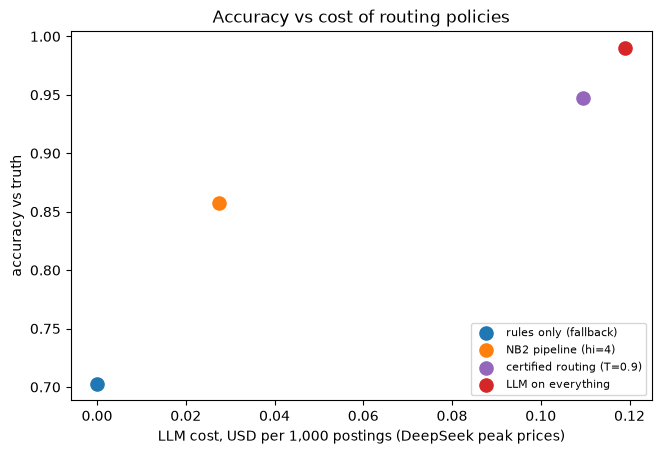

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for (k, (usd, acc)), c in zip(COST_ROWS.items(), [PALETTE["rules"], PALETTE["unresolved"], PALETTE["llm"], PALETTE["truth"]]):
    ax.scatter(usd, acc, s=90, color=c, label=k)
ax.set_xlabel("LLM cost, USD per 1,000 postings (DeepSeek peak prices)"); ax.set_ylabel("accuracy vs truth")
ax.set_title("Accuracy vs cost of routing policies"); ax.legend(fontsize=8, loc="lower right")
plt.show()

## Not built yet -- your call

This walkthrough is a **starting point** for extending it into your own project, not a finished system or a record of
production work. The next decisions are yours:

- **Real data and real labels.** Swap the synthetic generator for real postings (e.g. the Kaggle "LinkedIn Job Postings
  (2023 - 2024)" dataset) and the latent truth for real annotators, measuring inter-annotator agreement on the edge
  cases `LABEL_GUIDE` defines.
- **Scale the LLM proxy/oracle.** Section 1 only smoke-tests the logprob proxy and thinking oracle on 3 postings. Running
  them over a full batch is what turns section 2 into BARGAIN's own LLM-proxy setup; budget it first, and note the
  saturated logprobs (calibration drives utility).
- **Close the gaps the papers leave.** BARGAIN certifies against the oracle on a static batch, so decide how often
  to re-certify as data drifts, and keep PPI's human audit as the truth check. The combined monthly lifecycle here is
  this project's design, not something any of the three papers provides.
- **Tighter statistics.** Adaptive η for PPRM (shown in Notebook 1), the paper's exact CM-EB and betting bound for
  $U_0$, stratified PPI allocation across rule/LLM tiers (Fisch et al., NeurIPS 2024 -- further reading), and
  recall-target queries (hard when positives are rare).
- **A real provider.** Swap DeepSeek for Claude over raw HTTP (Notebook 2's mapping table), persist labels and
  monitor state (e.g. PostgreSQL), serve the monthly report (e.g. FastAPI), and grow the "keyword decoration" feature
  from section 5 into a real classifier.